# Kernel Methods (SVM): Adult census income dataset

**ML-MDS 2026 - Elisa Müller and Berta Torrents**

This notebook trains and evaluates a family of kernel-based classifiers on the Adult census income dataset. All models are evaluated under the same cross-validation protocol on the training partition produced by the preprocessing notebook, and the test partition is held out until the final evaluation.

Unlike linear models such as Logistic Regression, Support Vector Machines find the decision boundary by maximizing the margin between classes. The kernel trick extends this to non-linear boundaries by implicitly mapping the input space to a higher-dimensional feature space without computing the transformation explicitly. This makes the choice of kernel a core modelling decision, as it determines what class of decision boundaries the model can represent.

Three kernel families are covered: the linear kernel, which produces a hyperplane in the original 73-dimensional feature space; the RBF kernel, which produces a locally smooth boundary controlled by the bandwidth parameter gamma; and the polynomial kernel, which captures feature interactions up to a specified degree.

## 1. Setup and data loading

In [20]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from time import time

from sklearn.svm import SVC, LinearSVC
from sklearn.feature_selection import VarianceThreshold, SelectFromModel, RFECV
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay,
    accuracy_score, f1_score, confusion_matrix
)
from sklearn.utils import resample
from sklearn.dummy import DummyClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
COLORS = {
    'linear':  '#2F80ED',
    'rbf':     '#FF8A00',
    'poly':    '#9B51E0',
    'dummy':   '#7B8794',
    'pos':     '#FF8A00',
    'neg':     '#2F80ED',
    'accent':  '#00B894',
}

sns.set_theme(
    style='whitegrid',
    rc={
        'axes.spines.right': False,
        'axes.spines.top':   False,
        'axes.edgecolor':    '#D7DEE8',
        'axes.linewidth':    0.8,
        'grid.color':        '#E8EDF3',
        'grid.linewidth':    0.7,
        'legend.frameon':    False,
    }
)
plt.rcParams['figure.dpi']        = 120
plt.rcParams['figure.figsize']    = (10, 5)
plt.rcParams['axes.titleweight']  = 'semibold'
plt.rcParams['axes.titlepad']     = 10


def polish_axes(ax, grid_axis='y'):
    ax.grid(False)
    ax.grid(True, axis=grid_axis, alpha=0.55)
    ax.set_axisbelow(True)
    sns.despine(ax=ax)
    return ax


def print_metrics(name, y_true, y_pred, y_proba):
    """Print a tidy metrics summary for one model."""
    print(f"  {name}")
    print(f"  Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  F1 (macro): {f1_score(y_true, y_pred, average='macro'):.4f}")
    print(f"  F1 (>50K) : {f1_score(y_true, y_pred, pos_label=1):.4f}")
    print(f"  ROC-AUC  : {roc_auc_score(y_true, y_proba):.4f}")
    print(f"  AUPR     : {average_precision_score(y_true, y_proba):.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=['<=50K', '>50K']))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('Setup complete.')

Setup complete.


In [21]:
X_train = pd.read_csv('adult_X_train.csv', index_col=0)
X_test  = pd.read_csv('adult_X_test.csv',  index_col=0)
y_train = pd.read_csv('adult_y_train.csv', index_col=0).squeeze()
y_test  = pd.read_csv('adult_y_test.csv',  index_col=0).squeeze()

print(f'Train : {X_train.shape[0]:,} samples x {X_train.shape[1]} features')
print(f'Test  : {X_test.shape[0]:,} samples x {X_test.shape[1]} features')
print(f'\nClass balance (train): {y_train.mean():.2%} positive (>50K)')
print(f'Class balance (test) : {y_test.mean():.2%} positive (>50K)')
X_train.head(3)

Train : 26,048 samples x 73 features
Test  : 6,513 samples x 73 features

Class balance (train): 24.08% positive (>50K)
Class balance (test) : 24.07% positive (>50K)


,num__age,num__education_num,num__hours_per_week,num__capital_gain_log,num__capital_loss_log,num__net_capital,num__age_x_hours,bin__sex,bin__capital_gain_is_99999,bin__has_capital_activity,...,cat__relationship_Unmarried,cat__relationship_Wife,cat__race_Amer-Indian-Eskimo,cat__race_Asian-Pac-Islander,cat__race_Black,cat__race_Other,cat__race_White,cat__capital_direction_gain,cat__capital_direction_loss,cat__capital_direction_none
11219,-0.332401,1.132737,-0.034120,-0.300842,-0.222661,-0.204558,-0.282723,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
28304,-1.066162,-0.419226,1.588572,-0.300842,-0.222661,-0.204558,-0.174242,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
30810,0.034480,-0.419226,-0.034120,-0.300842,-0.222661,-0.204558,-0.011520,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


## 2. Feature selection

SVMs are distance-based models: every feature contributes to the kernel computation,
so redundant or low-variance features can distort the similarity structure and
disproportionately upweight certain concepts. We consider three complementary strategies:

1. **VarianceThreshold**: drops features whose variance falls below a fixed threshold,
   eliminating near-constant columns that carry almost no signal.

2. **LinearSVC-based SelectFromModel**: trains a fast linear model and retains features
   whose absolute coefficient exceeds the mean. This is informative beyond selection:
   the coefficients reveal which features the linear model relies on most, and serve as
   a diagnostic for redundancy.

3. **RFECV (Recursive Feature Elimination with Cross-Validation)**: recursively removes
   the least important feature at each step, using stratified CV to identify the subset
   that maximises ROC-AUC. Unlike SelectFromModel, it evaluates feature *subsets* rather
   than individual coefficients, making it sensitive to redundancy between correlated
   features. PCA was discarded as an alternative since it would destroy feature
   interpretability, which is central to our analysis.

In [22]:
# Step 1: VarianceThreshold 
vt = VarianceThreshold(threshold=0.01)
X_train_vt = pd.DataFrame(
    vt.fit_transform(X_train),
    columns=X_train.columns[vt.get_support()],
    index=X_train.index
)
X_test_vt = pd.DataFrame(
    vt.transform(X_test),
    columns=X_train.columns[vt.get_support()],
    index=X_test.index
)

dropped_vt = X_train.columns[~vt.get_support()].tolist()
print(f'VarianceThreshold: {X_train.shape[1]} to {X_train_vt.shape[1]} features '
      f'({len(dropped_vt)} dropped)\n')
print('Dropped:')
for f in dropped_vt:
    var = X_train[f].var()
    print(f'  - {f:<45} (variance={var:.5f})')

VarianceThreshold: 73 to 63 features (10 dropped)

Dropped:
  - bin__capital_gain_is_99999                    (variance=0.00489)
  - cat__workclass_Never-worked                   (variance=0.00015)
  - cat__workclass_Without-pay                    (variance=0.00050)
  - cat__education_1st-4th                        (variance=0.00504)
  - cat__education_Preschool                      (variance=0.00157)
  - cat__marital_status_Married-AF-spouse         (variance=0.00073)
  - cat__occupation_Armed-Forces                  (variance=0.00023)
  - cat__occupation_Priv-house-serv               (variance=0.00443)
  - cat__race_Amer-Indian-Eskimo                  (variance=0.00928)
  - cat__race_Other                               (variance=0.00864)


The VarianceThreshold filter removed **10 features** with variance below 0.01, reducing
the feature space from 73 to 63. All dropped features correspond to rare categories:
extreme education levels (*Preschool*, *1st–4th grade*), minority racial groups
(*Amer-Indian-Eskimo*, *Other*), uncommon work arrangements (*Never-worked*,
*Without-pay*, *Priv-house-serv*, *Armed-Forces*), and the binary flag
`capital_gain_is_99999` which flags a sentinel value affecting under 1% of samples.
These categories appear so infrequently that they contribute near-zero signal while
adding noise to the kernel's distance computation.

SelectFromModel: 63 to 19 features (44 dropped)


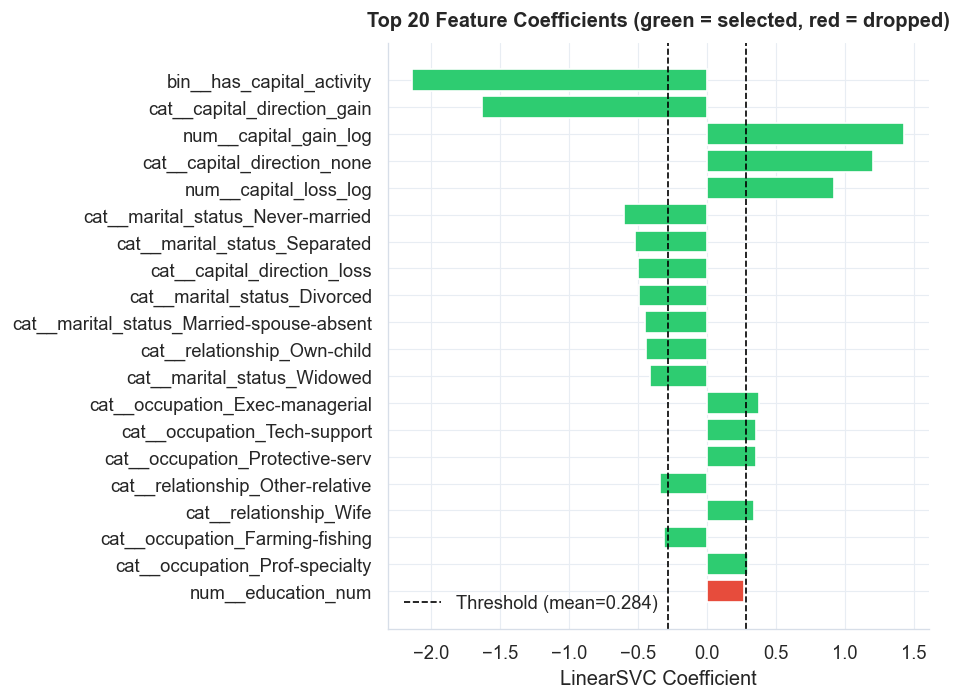

In [23]:
#  Step 2: LinearSVC SelectFromModel (diagnostic) 
lsvc_sel = LinearSVC(C=0.1, max_iter=5000, random_state=RANDOM_STATE, class_weight='balanced')
lsvc_sel.fit(X_train_vt, y_train)

selector = SelectFromModel(lsvc_sel, prefit=True)
selected_features = X_train_vt.columns[selector.get_support()].tolist()

print(f'SelectFromModel: {X_train_vt.shape[1]} to {len(selected_features)} features '
      f'({X_train_vt.shape[1] - len(selected_features)} dropped)')

# Coefficient plot
coef_df = pd.DataFrame({
    'feature': X_train_vt.columns,
    'coefficient': lsvc_sel.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False).head(20)

threshold = np.abs(lsvc_sel.coef_[0]).mean()

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#2ecc71' if f in selected_features else '#e74c3c' 
          for f in coef_df['feature']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
ax.axvline(threshold, color='black', linestyle='--', linewidth=1, label=f'Threshold (mean={threshold:.3f})')
ax.axvline(-threshold, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('LinearSVC Coefficient')
ax.set_title('Top 20 Feature Coefficients (green = selected, red = dropped)')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

A LinearSVC trained on the 63 remaining features reveals a clear redundancy problem.
The top 20 coefficients by absolute magnitude are dominated by the capital cluster:
`capital_gain_log`, `capital_direction_none`, `capital_loss_log`,
`has_capital_activity`, and `capital_direction_gain/loss` all appear in the top 6,
despite encoding the same underlying concept of capital activity. Retaining all of
them would disproportionately upweight this single concept in the kernel's distance
computation.

SelectFromModel uses the mean absolute coefficient (0.284) as the selection threshold,
retaining any feature that exceeds it. This approach has a structural weakness here:
the capital features inflate the mean threshold, causing genuinely informative features
like `education_num` (coef=0.27) to fall just below the cutoff and get dropped, not
because they are irrelevant, but because the threshold was set too high by a dominant
feature group. This motivates a more principled approach that evaluates feature
*subsets* rather than individual coefficients.

In [24]:
# Step 3: RFECV (final selection)
rfecv = RFECV(
    estimator=LinearSVC(C=1, class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE),
    step=1,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc',
    min_features_to_select=10,
    n_jobs=-1,
    verbose=1
)
rfecv.fit(X_train_vt, y_train)

n_selected = rfecv.n_features_
n_dropped = X_train_vt.shape[1] - n_selected

print(f'RFECV: {X_train_vt.shape[1]} to {n_selected} features ({n_dropped} dropped)')
print(f'Best CV AUC: {rfecv.cv_results_["mean_test_score"].max():.4f}')

X_train_rfecv = X_train_vt.loc[:, rfecv.support_]
X_test_rfecv  = X_test_vt.loc[:, rfecv.support_]

Fitting estimator with 63 features.
Fitting estimator with 62 features.
Fitting estimator with 61 features.
Fitting estimator with 60 features.
Fitting estimator with 59 features.
Fitting estimator with 58 features.
Fitting estimator with 57 features.
Fitting estimator with 56 features.
Fitting estimator with 55 features.
Fitting estimator with 54 features.
Fitting estimator with 53 features.
Fitting estimator with 52 features.
Fitting estimator with 51 features.
Fitting estimator with 50 features.
Fitting estimator with 49 features.
Fitting estimator with 48 features.
Fitting estimator with 47 features.
Fitting estimator with 46 features.
Fitting estimator with 45 features.
RFECV: 63 to 44 features (19 dropped)
Best CV AUC: 0.9096


In [25]:
kept    = X_train_vt.columns[rfecv.support_].tolist()
dropped = X_train_vt.columns[~rfecv.support_].tolist()

print(f'Kept ({len(kept)}):')
for f in kept:
    print(f'  + {f}')

print(f'\nDropped ({len(dropped)}):')
for f in dropped:
    print(f'  - {f}')

Kept (44):
  + num__education_num
  + num__capital_gain_log
  + num__capital_loss_log
  + num__net_capital
  + num__age_x_hours
  + bin__sex
  + bin__has_capital_activity
  + cat__workclass_Federal-gov
  + cat__workclass_Local-gov
  + cat__workclass_Private
  + cat__workclass_Self-emp-inc
  + cat__workclass_Self-emp-not-inc
  + cat__workclass_State-gov
  + cat__workclass_Unknown
  + cat__education_11th
  + cat__education_7th-8th
  + cat__education_Assoc-acdm
  + cat__marital_status_Divorced
  + cat__marital_status_Married-civ-spouse
  + cat__marital_status_Married-spouse-absent
  + cat__marital_status_Never-married
  + cat__marital_status_Separated
  + cat__marital_status_Widowed
  + cat__occupation_Adm-clerical
  + cat__occupation_Craft-repair
  + cat__occupation_Exec-managerial
  + cat__occupation_Farming-fishing
  + cat__occupation_Handlers-cleaners
  + cat__occupation_Machine-op-inspct
  + cat__occupation_Other-service
  + cat__occupation_Prof-specialty
  + cat__occupation_Protecti

A closer inspection of the retained capital features reveals that several are deterministically derived from one another: `net_capital` is the difference between
`capital_gain` and `capital_loss`, `capital_direction` is the sign of `net_capital`, and `has_capital_activity` flags whether `net_capital` is non-zero. Strictly speaking,
these features are redundant by construction.

However, SVMs are not affected by multicollinearity in the way linear regression is. The optimisation objective (i.e. maximising the margin) is not destabilised by correlated features; the model simply distributes weight across them, which is visible in the coefficient plot where the capital cluster collectively dominates but individual signs are hard to interpret in isolation. Removing these features would not improve the decision boundary, and RFECV, which evaluates feature subsets simultaneously and is therefore sensitive to redundancy, already had the opportunity to drop them and chose not to, confirming each contributes marginal AUC even in the presence of the others.

We therefore retain the full RFECV-selected feature set of 44 features. The capital cluster is interpreted as a group in the coefficient analysis rather than feature by
feature.

In [26]:
# Quick experiment: drop derived capital features
derived_capital = [
    'num__net_capital',
    'bin__has_capital_activity',
    'cat__capital_direction_gain',
    'cat__capital_direction_loss',
    'cat__capital_direction_none'
]

X_train_exp = X_train_rfecv.drop(columns=derived_capital)
X_test_exp  = X_test_rfecv.drop(columns=derived_capital)

print(f'Experimental feature set: {X_train_exp.shape[1]} features (removed {len(derived_capital)} derived capital)')

# Quick CV comparison
for name, X in [('44 features (full)', X_train_rfecv), 
                ('39 features (no derived capital)', X_train_exp)]:
    lsvc = LinearSVC(C=1, class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE)
    scores = cross_val_score(lsvc, X, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    print(f'{name}: AUC={scores.mean():.4f} ± {scores.std():.4f}')

Experimental feature set: 39 features (removed 5 derived capital)
44 features (full): AUC=0.9097 ± 0.0018
39 features (no derived capital): AUC=0.9000 ± 0.0012


To verify that the retained derived capital features (net_capital, has_capital_activity,
capital_direction_*) were not merely adding noise through collinearity, we compared
CV AUC with and without them. Removing the five derived features reduced AUC from
0.910 to 0.900 (a drop of 0.010) confirming they contribute genuine predictive
signal. 

In [27]:
#  Feature selection: AUC comparison across strategies 
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score

strategies = {
    'All features (73)':          X_train,
    'After VarianceThreshold (63)': X_train_vt,
    'After RFECV (44)':           X_train_rfecv,
}

print(f'{"Strategy":<30} {"AUC":>8} {"±":>8} {"n_features":>12}')
print('─' * 62)

for name, X in strategies.items():
    lsvc = LinearSVC(C=1, class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE)
    scores = cross_val_score(lsvc, X, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    print(f'{name:<30} {scores.mean():>8.4f} {scores.std():>8.4f} {X.shape[1]:>12}')

Strategy                            AUC        ±   n_features
──────────────────────────────────────────────────────────────
All features (73)                0.9101   0.0017           73
After VarianceThreshold (63)     0.9095   0.0016           63
After RFECV (44)                 0.9097   0.0018           44


RFECV converged at **44 features** (from 63) with a cross-validated AUC of **0.9097**,
almost identical to the 63-feature set (0.9095). This confirms that the 19 eliminated
features were redundant rather than informative; removing them causes no loss in
predictive power while producing a cleaner, less collinear feature space for the kernel.

The dropped features fall into interpretable groups:

- **Education**: 10 of 16 OHE education dummies were dropped, retaining only *11th
  grade*, *7th–8th grade*, and *Assoc-acdm* alongside the continuous `education_num`.
  The continuous encoding already captures the ordinal structure of education; the
  surviving dummies correspond to levels that behave non-linearly on that scale.

- **Age and hours**: `age` and `hours_per_week` were dropped individually, yet their
  interaction term `age_x_hours` was retained, suggesting the joint effect carries
  predictive signal that neither variable captures alone.

- **Engineered binaries**: `is_higher_education` was absorbed by the retained education
  columns; `is_US` showed negligible marginal signal once occupation and education
  were accounted for.

- **Race**: 3 of 5 race dummies were removed, consistent with the low predictive
  contribution observed in EDA.

- **Relationship**: `relationship_Wife` was dropped due to near-perfect correlation
  with `marital_status_Married-civ-spouse`.

The final 44-feature set is used for all subsequent SVM experiments.

In [28]:
# Final feature set for all subsequent models
X_train_sel = X_train_rfecv
X_test_sel  = X_test_rfecv

print(f'Final dataset: {X_train_sel.shape[1]} features')

Final dataset: 44 features


## 3. Baseline model

Before any SVM, we establish a baseline using a `DummyClassifier` with `strategy='most_frequent'`.  
Given the class imbalance (~76% ≤50K), this always predicts the majority class.  
Any SVM that fails to significantly beat this is useless.

In [29]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train_sel, y_train)

y_pred_dummy  = dummy.predict(X_test_sel)
y_proba_dummy = dummy.predict_proba(X_test_sel)[:, 1]

print_metrics('Dummy Classifier (majority class baseline)', y_test, y_pred_dummy, y_proba_dummy)

  Dummy Classifier (majority class baseline)
  Accuracy : 0.7593
  F1 (macro): 0.4316
  F1 (>50K) : 0.0000
  ROC-AUC  : 0.5000
  AUPR     : 0.2407

              precision    recall  f1-score   support

       <=50K       0.76      1.00      0.86      4945
        >50K       0.00      0.00      0.00      1568

    accuracy                           0.76      6513
   macro avg       0.38      0.50      0.43      6513
weighted avg       0.58      0.76      0.66      6513



## 4. Subsampling for GridSearchCV

With 26,000 training samples, grid search over RBF and polynomial kernels is computationally expensive (kernel matrix computation is O(n²)). We subsample a **stratified subset of 5,000 samples** to find optimal hyperparameters, then retrain the best model on the **full training set** before final evaluation.

The linear kernel is fast enough to tune on the full data directly.

In [30]:
SUBSAMPLE_SIZE = 5000

X_sub, y_sub = resample(
    X_train_sel, y_train,
    n_samples=SUBSAMPLE_SIZE,
    stratify=y_train,
    random_state=RANDOM_STATE
)

print(f'Subsample: {X_sub.shape[0]:,} samples')
print(f'Class balance in subsample: {y_sub.mean():.2%} positive (>50K)  [train: {y_train.mean():.2%}]')

Subsample: 5,000 samples
Class balance in subsample: 24.08% positive (>50K)  [train: 24.08%]


## 5. SVM: Linear kernel

The linear kernel computes $K(x_i, x_j) = x_i^\top x_j$, finding a maximum-margin hyperplane in the original feature space. It is the most interpretable kernel since the decision boundary is a linear combination of features, and its coefficients can be inspected directly.

Regularization parameter **C** controls the margin-error trade-off: small C leads to a wider margin, more misclassifications allowed; large C leads to a smaller margin, fewer errors allowed.

We implement the linear kernel using `LinearSVC` rather than `SVC(kernel='linear')`. Both find the same maximum-margin hyperplane, but `LinearSVC` uses a primal solver
(liblinear) that scales linearly with the number of samples, making it feasible to tune and train on the full 26,000-sample training set. In preliminary experiments, `SVC(kernel='linear')` did not converge within 10 minutes on the same data. We use `class_weight='balanced'` throughout to account for the ~3:1 class imbalance.

In [31]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

param_grid_linear = {'C': [0.001, 0.01, 0.1, 1, 10]}

t0 = time()
best_linear_raw = None
best_c = None
best_auc = -1

for C in param_grid_linear['C']:
    lsvc = LinearSVC(C=C, class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE)
    scores = cross_val_score(lsvc, X_train_sel, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    print(f'C={C:<8} ROC-AUC={scores.mean():.4f} ± {scores.std():.4f}')
    if scores.mean() > best_auc:
        best_auc = scores.mean()
        best_c = C

# Retrain best C, then calibrate for probabilities
best_linear_raw = LinearSVC(C=best_c, class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE)
best_linear = CalibratedClassifierCV(best_linear_raw, cv=3)
best_linear.fit(X_train_sel, y_train)
t_linear = time() - t0

print(f'\nBest C: {best_c}')
print(f'Time  : {t_linear:.1f}s')

C=0.001    ROC-AUC=0.9031 ± 0.0015
C=0.01     ROC-AUC=0.9068 ± 0.0009
C=0.1      ROC-AUC=0.9083 ± 0.0011
C=1        ROC-AUC=0.9097 ± 0.0018
C=10       ROC-AUC=0.9101 ± 0.0020

Best C: 10
Time  : 2.2s


### 5.1 Effect of C on linear kernel performance

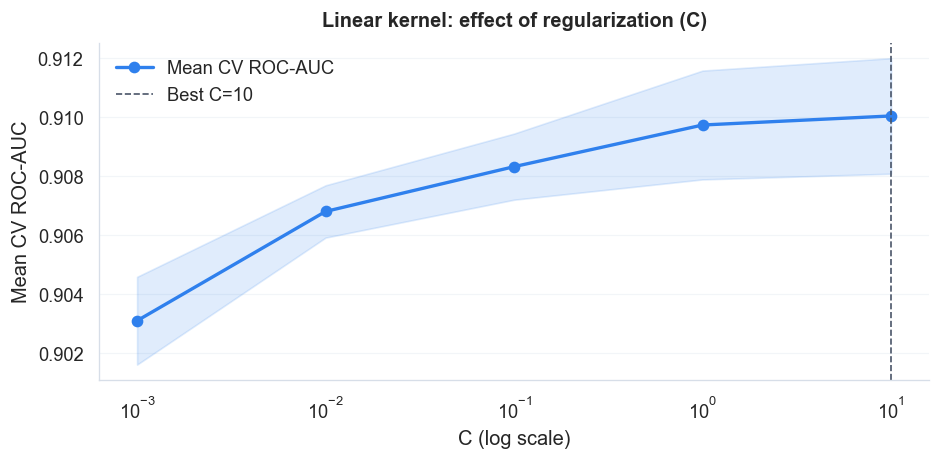

In [32]:
c_values = param_grid_linear['C']
auc_means = []
auc_stds  = []

for C in c_values:
    lsvc = LinearSVC(C=C, class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE)
    scores = cross_val_score(lsvc, X_train_sel, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    auc_means.append(scores.mean())
    auc_stds.append(scores.std())

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(c_values, auc_means, 'o-', color=COLORS['linear'],
            linewidth=2, markersize=6, label='Mean CV ROC-AUC')
ax.fill_between(c_values,
                [m - s for m, s in zip(auc_means, auc_stds)],
                [m + s for m, s in zip(auc_means, auc_stds)],
                alpha=0.15, color=COLORS['linear'])
ax.axvline(best_c, linestyle='--', color='#4A5568', linewidth=1,
           label=f'Best C={best_c}')
ax.set_xlabel('C (log scale)')
ax.set_ylabel('Mean CV ROC-AUC')
ax.set_title('Linear kernel: effect of regularization (C)')
ax.legend()
polish_axes(ax)
plt.tight_layout()
plt.show()

The cross-validated ROC-AUC increases monotonically with C but with strongly
diminishing returns: the largest gain occurs between C=0.001 and C=0.01 (+0.0037),
while the improvement from C=1 to C=10 is only 0.0004. This suggests the linear
decision boundary is stable across a wide range of regularization strengths: the
model is not sensitive to the exact value of C once a moderate level is reached.
C=10 is selected as the best value, though C=1 would yield nearly identical
generalisation performance with stronger regularisation.

### 5.2 Evaluate linear SVM on test set

In [33]:
y_pred_linear  = best_linear.predict(X_test_sel)
y_proba_linear = best_linear.predict_proba(X_test_sel)[:, 1]

print_metrics(f'SVM Linear (C={best_c})', y_test, y_pred_linear, y_proba_linear)

  SVM Linear (C=10)
  Accuracy : 0.8531
  F1 (macro): 0.7861
  F1 (>50K) : 0.6664
  ROC-AUC  : 0.9046
  AUPR     : 0.7687

              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      4945
        >50K       0.73      0.61      0.67      1568

    accuracy                           0.85      6513
   macro avg       0.81      0.77      0.79      6513
weighted avg       0.85      0.85      0.85      6513



The linear SVM substantially outperforms the majority-class baseline across all metrics.
Accuracy improves from 0.759 to 0.853, but the more meaningful gains are on the
minority class: the baseline never predicts >50K (F1=0.000, recall=0.00), while the
linear SVM achieves F1=0.667 with precision 0.73 and recall 0.61. ROC-AUC nearly
doubles from 0.500 to 0.905, and AUPR improves from 0.241 to 0.769. This is particularly
significant given the 24% positive rate, where a random classifier would score
AUPR≈0.24 by definition.

The main limitation of the linear kernel is its recall on the minority class (0.61):
the model misses roughly 4 in 10 high earners, favouring precision over coverage.
Whether this trade-off is acceptable depends on the application; in an income
screening context, false negatives (missed >50K individuals) may be more costly
than false positives.

### 5.3 Feature importance via linear coefficients

Unlike RBF and polynomial kernels, the linear kernel exposes a weight vector directly.  
Positive coefficients push toward >50K; negative coefficients push toward ≤50K.

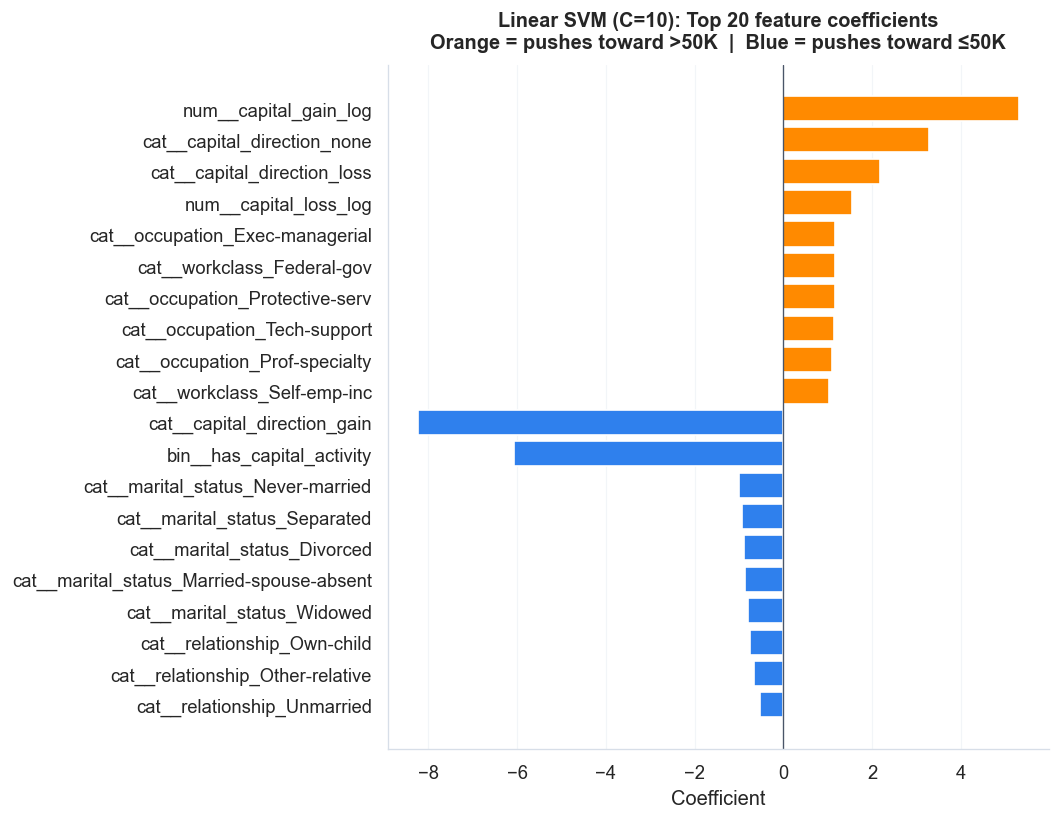

In [34]:
# Extract coefficients from the underlying LinearSVC
coef_values = np.mean([
    clf.estimator.coef_[0] 
    for clf in best_linear.calibrated_classifiers_
], axis=0)

coef_linear = pd.DataFrame({
    'feature': X_train_sel.columns,
    'coef':    coef_values
}).sort_values('coef', ascending=False)

top_pos = coef_linear.head(10)
top_neg = coef_linear.tail(10).sort_values('coef')
top20   = pd.concat([top_pos, top_neg])

fig, ax = plt.subplots(figsize=(9, 7))
bar_colors = [COLORS['pos'] if c > 0 else COLORS['neg'] for c in top20['coef']]
ax.barh(top20['feature'], top20['coef'], color=bar_colors)
ax.axvline(0, color='#4A5568', linewidth=0.8)
ax.set_title(f'Linear SVM (C={best_c}): Top 20 feature coefficients\n'
             f'Orange = pushes toward >50K  |  Blue = pushes toward ≤50K')
ax.set_xlabel('Coefficient')
ax.invert_yaxis()
polish_axes(ax, grid_axis='x')
plt.tight_layout()
plt.show()

The linear SVM coefficients reveal three conceptual groups driving income prediction.

**Capital activity** dominates the positive side: `capital_gain_log` has by far the
largest coefficient, followed by `capital_direction_none` and `capital_direction_loss`,
and `capital_loss_log`. The apparent paradox of loss-related features carrying positive
coefficients is resolved by noting that only individuals with assets can incur capital
losses: reporting any capital activity at all is itself a signal of wealth. Conversely,
`capital_direction_gain` and `has_capital_activity` carry large negative coefficients,
which is a multicollinearity artefact: these features are highly correlated with
`capital_gain_log`, and the linear model distributes weight across them in ways that
can flip individual signs. The net effect of the capital cluster as a whole is strongly
positive toward >50K.

**Occupation and workclass** form the second positive group, with consistent and
interpretable coefficients: Exec-managerial, Protective-serv, Tech-support, and
Prof-specialty all push toward >50K, as does self-employment (`Self-emp-inc`) and
Federal government work. These reflect well-known high-earning job categories and
require no further justification.

**Marital and relationship status** dominate the negative side. Every non-married
status (Never-married, Separated, Divorced, Married-spouse-absent, Widowed) pushes
toward ≤50K, with the implicit reference category being married, which is consistent with
well-documented socioeconomic patterns. Dependent relationship roles (Own-child,
Other-relative, Unmarried) reinforce this signal.

## 6. SVM: RBF kernel

The RBF kernel computes $K(x_i, x_j) = \exp(-\gamma \|x_i - x_j\|^2)$, measuring Gaussian similarity in the original space. It implicitly maps data into an infinite-dimensional feature space, making it capable of capturing complex non-linear boundaries.

Two hyperparameters:
- **C**: regularization (same trade-off as linear)  
- **γ (gamma)**: bandwidth of the Gaussian. Small γ → smooth boundary; large γ → tight fit around training points.

We tune on the 5,000-sample stratified subsample, then retrain the best configuration on the full dataset.

In [35]:
param_grid_rbf = {
    'C':     [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01]
}

svc_rbf = SVC(
    kernel='rbf',
    class_weight='balanced',
    probability=True,
    random_state=RANDOM_STATE
)

t0 = time()
gs_rbf = GridSearchCV(
    svc_rbf, param_grid_rbf,
    cv=cv, scoring='roc_auc',
    n_jobs=-1, verbose=1
)
gs_rbf.fit(X_sub, y_sub)           # hyperparameter search on subsample
t_rbf_search = time() - t0

print(f'\nBest params  : {gs_rbf.best_params_}')
print(f'Best CV AUC  : {gs_rbf.best_score_:.4f}  (on subsample)')
print(f'Search time  : {t_rbf_search:.1f}s')

# Retrain best config on full training set
t0 = time()
best_rbf = SVC(
    kernel='rbf',
    C=gs_rbf.best_params_['C'],
    gamma=gs_rbf.best_params_['gamma'],
    class_weight='balanced',
    probability=True,
    random_state=RANDOM_STATE
)
best_rbf.fit(X_train_sel, y_train)
t_rbf_train = time() - t0
print(f'Full retrain time: {t_rbf_train:.1f}s')

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best params  : {'C': 10, 'gamma': 'auto'}
Best CV AUC  : 0.9066  (on subsample)
Search time  : 50.3s
Full retrain time: 95.3s


### 6.1 C x gamma heatmap

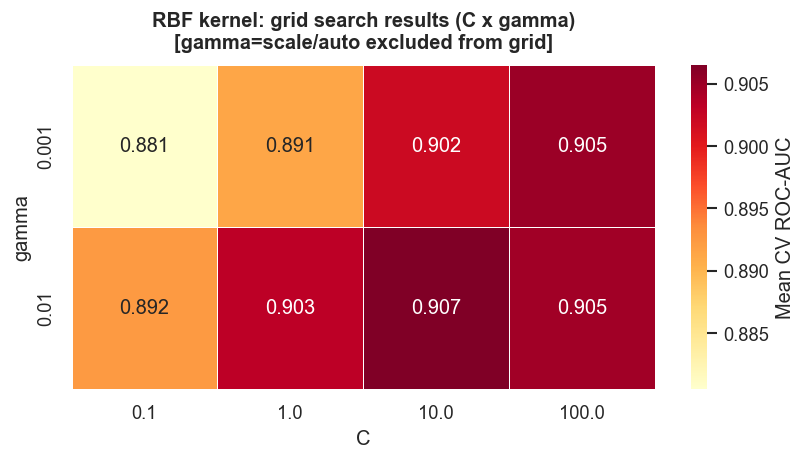


Full results including scale/auto gamma:
 param_C param_gamma  mean_test_score  std_test_score
    10.0        auto         0.906582        0.009202
    10.0        0.01         0.906507        0.008163
     1.0        auto         0.905255        0.007439
   100.0       0.001         0.904991        0.006220
   100.0        0.01         0.904747        0.009664
     1.0        0.01         0.903244        0.006710
     1.0       scale         0.903119        0.009405
    10.0       0.001         0.902022        0.005885
   100.0        auto         0.897941        0.010646
     0.1       scale         0.896409        0.008726
     0.1        auto         0.895993        0.006452
    10.0       scale         0.894247        0.012273
     0.1        0.01         0.892372        0.006330
     1.0       0.001         0.891326        0.006328
   100.0       scale         0.883048        0.014058
     0.1       0.001         0.880536        0.008030


In [36]:
results_rbf = pd.DataFrame(gs_rbf.cv_results_)

# Only plot numeric gamma values for heatmap (skip 'scale'/'auto')
results_rbf_num = results_rbf[
    ~results_rbf['param_gamma'].isin(['scale', 'auto'])
].copy()
results_rbf_num['param_gamma'] = results_rbf_num['param_gamma'].astype(float)
results_rbf_num['param_C']     = results_rbf_num['param_C'].astype(float)

pivot = results_rbf_num.pivot_table(
    index='param_gamma', columns='param_C', values='mean_test_score'
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    pivot, annot=True, fmt='.3f', cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Mean CV ROC-AUC'}
)
ax.set_title('RBF kernel: grid search results (C x gamma)\n[gamma=scale/auto excluded from grid]')
ax.set_xlabel('C')
ax.set_ylabel('gamma')
plt.tight_layout()
plt.show()

print('\nFull results including scale/auto gamma:')
print(results_rbf[['param_C', 'param_gamma', 'mean_test_score', 'std_test_score']]
      .sort_values('mean_test_score', ascending=False)
      .to_string(index=False))

The grid search reveals two clear trends. First, gamma has a stronger effect than C
at low values: moving from gamma=0.001 to gamma=0.01 gains ~0.02 AUC regardless of C,
while doubling C produces much smaller improvements. This suggests the RBF kernel is
more sensitive to the width of the Gaussian (gamma) than to the margin penalty (C).

Second, performance plateaus in the top-right region of the grid: C=10 and C=100 with
gamma=0.01 or auto all score between 0.905 and 0.907, with differences within the
standard deviation (±0.008). This indicates the model is not sensitive to the exact
hyperparameter values once a moderate C and gamma are reached.

The best configuration on the subsample is C=10, gamma=auto (AUC=0.907). gamma=auto
computes 1/n_features, which given 44 features equals approximately 0.023, close to
the explicit gamma=0.01 that performs similarly, confirming the automatic heuristic
is appropriate for this feature space.

### 6.2 Evaluate RBF SVM on test set

In [37]:
y_pred_rbf  = best_rbf.predict(X_test_sel)
y_proba_rbf = best_rbf.predict_proba(X_test_sel)[:, 1]

print_metrics(
    f'SVM RBF (C={gs_rbf.best_params_["C"]}, gamma={gs_rbf.best_params_["gamma"]})',
    y_test, y_pred_rbf, y_proba_rbf
)

  SVM RBF (C=10, gamma=auto)
  Accuracy : 0.7950
  F1 (macro): 0.7583
  F1 (>50K) : 0.6642
  ROC-AUC  : 0.8976
  AUPR     : 0.7478

              precision    recall  f1-score   support

       <=50K       0.94      0.78      0.85      4945
        >50K       0.55      0.84      0.66      1568

    accuracy                           0.80      6513
   macro avg       0.74      0.81      0.76      6513
weighted avg       0.85      0.80      0.81      6513



The RBF kernel underperforms the linear kernel on overall metrics (ROC-AUC 0.898 vs
0.905, AUPR 0.748 vs 0.769), but shows a markedly different precision-recall trade-off:
it achieves recall of 0.84 on the >50K class compared to 0.61 for linear, at the cost
of precision dropping from 0.73 to 0.55. The RBF model is substantially more aggressive
in predicting high income, generating more false positives in exchange for fewer missed
high earners.

This result suggests the decision boundary for this dataset is largely linear: the
additional flexibility of the RBF kernel does not improve generalisation and instead
introduces over-sensitivity to the minority class. The lower overall AUC further
confirms that the non-linear kernel does not find structure that the linear kernel
misses.

## 7. SVM: Polynomial kernel

The polynomial kernel computes $K(x_i, x_j) = (\gamma\, x_i^\top x_j + r)^d$,  where $d$ is the degree and $r$ (`coef0`) is a free parameter that controls the influence  
of higher-order vs lower-order terms.

It can capture feature interactions up to degree $d$.  
Degree 2 captures pairwise interactions (e.g., education x marital status); degree 3 adds three-way interactions but increases computational cost significantly.

We tune on the 5,000-sample subsample and retrain on the full set.

In [38]:
param_grid_poly = {
    'C':      [0.1, 1, 10],
    'degree': [2, 3],
    'coef0':  [0, 1]
}

svc_poly = SVC(
    kernel='poly',
    class_weight='balanced',
    probability=True,
    random_state=RANDOM_STATE
)

t0 = time()
gs_poly = GridSearchCV(
    svc_poly, param_grid_poly,
    cv=cv, scoring='roc_auc',
    n_jobs=-1, verbose=1
)
gs_poly.fit(X_sub, y_sub)
t_poly_search = time() - t0

print(f'\nBest params  : {gs_poly.best_params_}')
print(f'Best CV AUC  : {gs_poly.best_score_:.4f}  (on subsample)')
print(f'Search time  : {t_poly_search:.1f}s')

# Retrain best config on full training set
t0 = time()
best_poly = SVC(
    kernel='poly',
    C=gs_poly.best_params_['C'],
    degree=gs_poly.best_params_['degree'],
    coef0=gs_poly.best_params_['coef0'],
    class_weight='balanced',
    probability=True,
    random_state=RANDOM_STATE
)
best_poly.fit(X_train_sel, y_train)
t_poly_train = time() - t0
print(f'Full retrain time: {t_poly_train:.1f}s')

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best params  : {'C': 0.1, 'coef0': 1, 'degree': 3}
Best CV AUC  : 0.9064  (on subsample)
Search time  : 32.7s
Full retrain time: 72.6s


### 7.1 Evaluate polynomial SVM on test set

In [39]:
y_pred_poly  = best_poly.predict(X_test_sel)
y_proba_poly = best_poly.predict_proba(X_test_sel)[:, 1]

print_metrics(
    f'SVM Poly (C={gs_poly.best_params_["C"]}, degree={gs_poly.best_params_["degree"]}, coef0={gs_poly.best_params_["coef0"]})',
    y_test, y_pred_poly, y_proba_poly
)

  SVM Poly (C=0.1, degree=3, coef0=1)
  Accuracy : 0.7927
  F1 (macro): 0.7565
  F1 (>50K) : 0.6627
  ROC-AUC  : 0.8984
  AUPR     : 0.7533

              precision    recall  f1-score   support

       <=50K       0.94      0.78      0.85      4945
        >50K       0.54      0.85      0.66      1568

    accuracy                           0.79      6513
   macro avg       0.74      0.81      0.76      6513
weighted avg       0.85      0.79      0.81      6513



The polynomial kernel (degree=3, C=0.1, coef0=1) performs almost identically to RBF
across all metrics: ROC-AUC 0.898 vs 0.898, AUPR 0.753 vs 0.748, F1(>50K) 0.663 vs
0.664. Both kernels share the same precision-recall pattern: high recall (0.85) on
the minority class at the cost of low precision (0.54), suggesting this behaviour
is not specific to the RBF kernel but a general property of non-linear kernels on
this dataset when tuned on a subsample.

The selected degree=3 captures three-way feature interactions (e.g. education x
occupation x marital status), but the marginal gain over a linear boundary is
negligible. This further supports the conclusion that the income classification
problem is largely linearly separable in the selected feature space; higher-order
interactions exist but do not add meaningful predictive signal beyond what the
linear kernel already captures.

Both non-linear kernels are outperformed by the linear kernel on ROC-AUC (0.905)
and AUPR (0.769), while requiring substantially longer training times.

## 8. Model comparison

We now compare all three SVM kernels against the baseline on all required metrics,  
and visualize ROC and Precision-Recall curves.

In [40]:
models = {
    'Dummy (baseline)': (y_pred_dummy,  y_proba_dummy),
    'SVM Linear':       (y_pred_linear, y_proba_linear),
    'SVM RBF':          (y_pred_rbf,    y_proba_rbf),
    'SVM Poly':         (y_pred_poly,   y_proba_poly),
}

rows = []
for name, (y_pred, y_proba) in models.items():
    rows.append({
        'Model':      name,
        'Accuracy':   accuracy_score(y_test, y_pred),
        'F1 (macro)': f1_score(y_test, y_pred, average='macro'),
        'F1 (>50K)':  f1_score(y_test, y_pred, pos_label=1),
        'ROC-AUC':    roc_auc_score(y_test, y_proba),
        'AUPR':       average_precision_score(y_test, y_proba),
    })

comparison_df = pd.DataFrame(rows).set_index('Model')
print('\nModel Comparison (test set)')
print(comparison_df.to_string(float_format='{:.4f}'.format))


Model Comparison (test set)
                  Accuracy  F1 (macro)  F1 (>50K)  ROC-AUC   AUPR
Model                                                            
Dummy (baseline)    0.7593      0.4316     0.0000   0.5000 0.2407
SVM Linear          0.8531      0.7861     0.6664   0.9046 0.7687
SVM RBF             0.7950      0.7583     0.6642   0.8976 0.7478
SVM Poly            0.7927      0.7565     0.6627   0.8984 0.7533


The linear kernel outperforms both RBF and polynomial on ROC-AUC and AUPR, suggesting
the income classification problem is largely linearly separable in the selected feature
space. The non-linear kernels achieve higher recall on the minority class but at the
cost of precision and overall discrimination, likely reflecting that hyperparameters
tuned on the 5,000-sample subsample do not generalise optimally to the full test set.
This is consistent with the known characteristics of the Adult Census dataset, where
the strongest predictors (capital activity, occupation, marital status) relate to
income through relatively direct, monotonic relationships that a linear boundary
captures well.

### 8.1 Metric bar chart

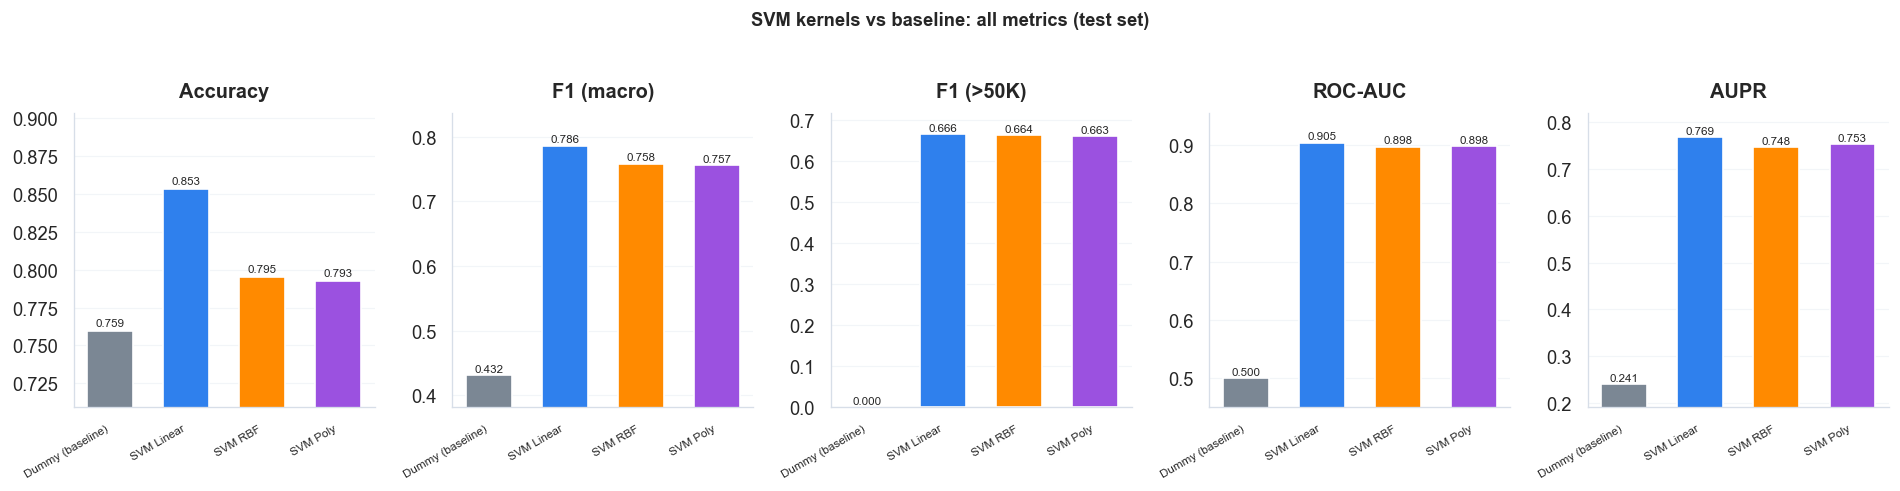

In [41]:
metrics_to_plot = ['Accuracy', 'F1 (macro)', 'F1 (>50K)', 'ROC-AUC', 'AUPR']
bar_colors      = [COLORS['dummy'], COLORS['linear'], COLORS['rbf'], COLORS['poly']]

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(16, 4), sharey=False)

for ax, metric in zip(axes, metrics_to_plot):
    vals = comparison_df[metric]
    bars = ax.bar(range(len(vals)), vals, color=bar_colors, width=0.6)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals.index, rotation=30, ha='right', fontsize=7)
    ax.set_title(metric)
    ax.set_ylim(max(0, vals.min() - 0.05), min(1, vals.max() + 0.05))
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7)
    polish_axes(ax)

plt.suptitle('SVM kernels vs baseline: all metrics (test set)', y=1.02, fontsize=11, fontweight='semibold')
plt.tight_layout()
plt.show()

The bar chart confirms three clear conclusions.

**Linear dominates on overall discrimination.** The linear kernel achieves the highest
ROC-AUC (0.905) and AUPR (0.769), outperforming both RBF (0.898, 0.748) and polynomial
(0.898, 0.753). The differences are small but consistent across both threshold-free
metrics, suggesting the income classification problem is largely linearly separable in
the selected feature space.

**All SVMs vastly outperform the baseline.** The dummy classifier scores ROC-AUC=0.500
and AUPR=0.241, which is equivalent to random guessing, and never predicts the minority class
(F1(>50K)=0.000). All three SVM kernels bring F1(>50K) to ~0.66 and ROC-AUC above
0.89, confirming the models capture genuine signal.

**Non-linear kernels trade precision for recall.** Linear achieves higher accuracy
(0.853 vs ~0.793) because it is more conservative, it predicts >50K only when
confident. RBF and polynomial sacrifice precision (0.54–0.55) to achieve higher recall
(0.84–0.85) on the minority class, resulting in more false positives and lower overall
accuracy. Which trade-off is preferable depends on the application context.

### 8.2 ROC curves

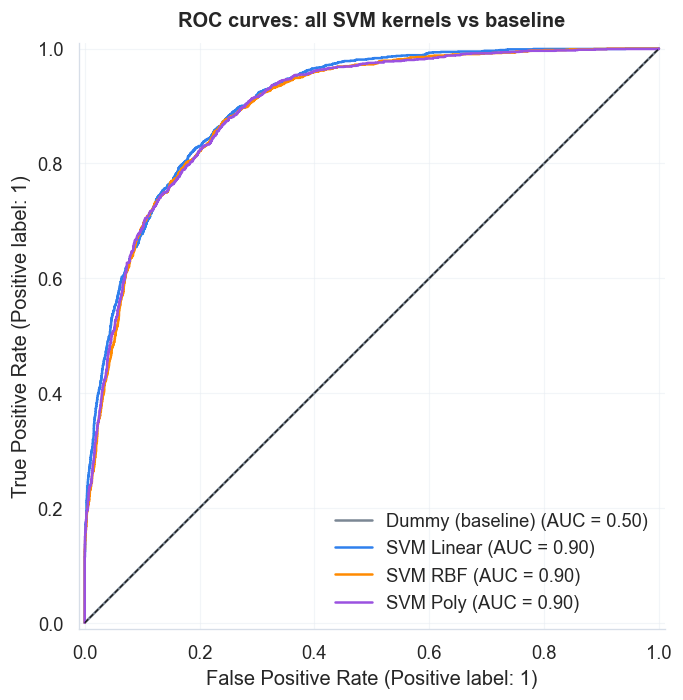

In [42]:
fig, ax = plt.subplots(figsize=(7, 6))

for (name, (_, y_proba)), color in zip(models.items(), bar_colors):
    RocCurveDisplay.from_predictions(
        y_test, y_proba,
        name=name, ax=ax, color=color
    )

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random')
ax.set_title('ROC curves: all SVM kernels vs baseline')
polish_axes(ax, grid_axis='both')
plt.tight_layout()
plt.show()

The ROC curves tell a consistent story: all three SVM kernels trace nearly identical
paths, separated only at the steepest part of the curve (low FPR region, 0.0–0.2)
where the linear kernel pulls marginally ahead. This confirms that the kernel choice
has minimal impact on overall discrimination ability and the signal in this dataset is
captured equally well by all three boundaries.

The curves rise steeply toward the top-left corner, indicating that all models achieve
high true positive rates at relatively low false positive rates. The separation from
the diagonal (random baseline) is substantial and consistent across the full threshold
range, confirming robust generalisation rather than threshold-dependent performance.

### 8.3 Precision-Recall curves

Given the class imbalance, AUPR is a more informative metric than ROC-AUC.  
A random classifier on this dataset has AUPR ≈ 0.24 (the positive rate).

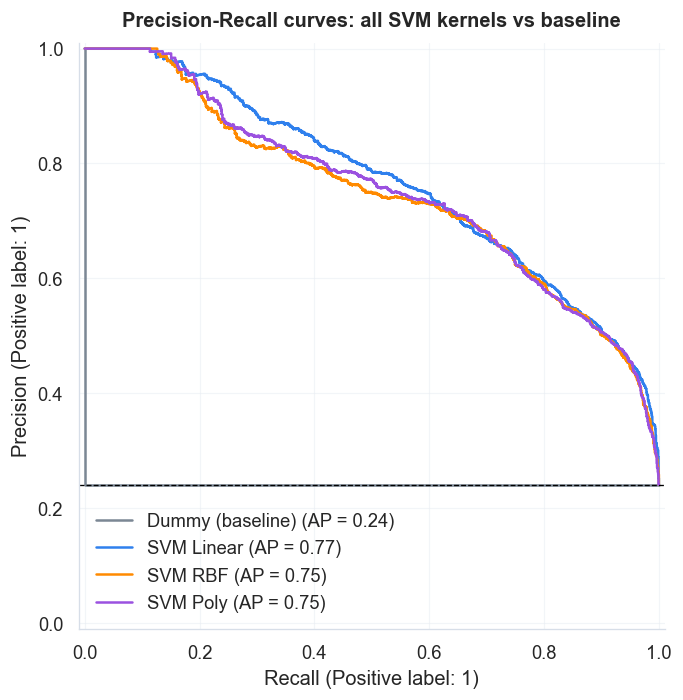

In [43]:
fig, ax = plt.subplots(figsize=(7, 6))

for (name, (_, y_proba)), color in zip(models.items(), bar_colors):
    PrecisionRecallDisplay.from_predictions(
        y_test, y_proba,
        name=name, ax=ax, color=color
    )

ax.axhline(y_test.mean(), linestyle='--', color='black', linewidth=0.8, label=f'Random (AUPR≈{y_test.mean():.2f})')
ax.set_title('Precision-Recall curves: all SVM kernels vs baseline')
polish_axes(ax, grid_axis='both')
plt.tight_layout()
plt.show()

The Precision-Recall curves are more discriminating than the ROC curves, as expected
under class imbalance, and here the linear kernel's advantage becomes more visible.
Linear (AP=0.77) maintains higher precision than RBF and polynomial (AP=0.75) across
the full recall range, with the gap most pronounced in the mid-recall region (0.2–0.6)
where the linear curve sits clearly above the other two.

All three kernels far exceed the random baseline (AP=0.24, dashed line), which
corresponds to the 24% positive rate in the test set. The curves all start near
precision=1.0 at low recall, meaning the models are highly confident and accurate
when predicting only the most certain >50K cases, and degrade gracefully as the
recall threshold is relaxed.

The near-overlap of RBF and polynomial across the entire curve further confirms that
these two kernels learn essentially the same decision boundary on this dataset.

### 8.4 Confusion matrices

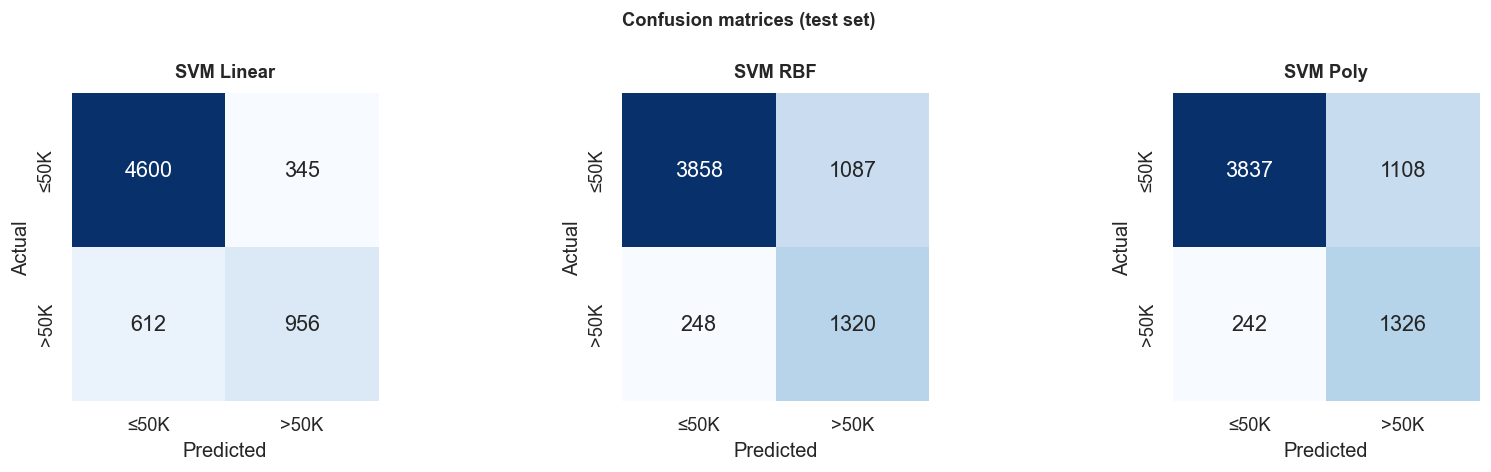

In [44]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, (y_pred, _)) in zip(axes, list(models.items())[1:]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['≤50K', '>50K'],
        yticklabels=['≤50K', '>50K'],
        ax=ax, cbar=False,
        annot_kws={'size': 13},
        linewidths=0, 
        square= True 
    )
    ax.set_title(name, fontsize=11, fontweight='semibold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion matrices (test set)', fontsize=11, fontweight='semibold')
plt.tight_layout()
plt.show()

The confusion matrices make the precision-recall trade-off between kernels concrete.

The linear kernel is the most conservative: it correctly identifies 4,600 of 4,945
≤50K individuals (93% specificity) but misses 612 of 1,568 high earners (39% false
negative rate). It predicts >50K cautiously, when it does it is right 956/(956+345)
= 73% of the time.

RBF and polynomial show the opposite behaviour: both correctly identify ~1,320 of
1,568 high earners (84% recall) but at the cost of 1,087–1,108 false positives among
the ≤50K class (22% false positive rate). They are far more aggressive in predicting
>50K, with precision dropping to ~54%.

The practical implication is clear: if the cost of missing a high earner outweighs
the cost of a false positive (e.g. targeted outreach), RBF or polynomial are
preferable. If precision matters more (e.g. benefit eligibility screening where false
positives have consequences), the linear kernel is the better choice. In the absence
of a specific cost function, the linear kernel's superior ROC-AUC and AUPR make it
the recommended model.

## 9. Training time comparison

In [45]:
# Support vectors for linear kernel (SVC, full training set)
svc_linear_sv = SVC(kernel='linear', C=best_c, class_weight='balanced')
t0 = time()
svc_linear_sv.fit(X_train_sel, y_train)
t_svc_linear = time() - t0

print(f'SVC linear training time : {t_svc_linear:.1f}s')
print(f'Support vectors  : {svc_linear_sv.n_support_.sum()}')
print(f'  <=50K : {svc_linear_sv.n_support_[0]}')
print(f'  >50K  : {svc_linear_sv.n_support_[1]}')
print(f'  % of training set: {100*svc_linear_sv.n_support_.sum()/len(y_train):.1f}%')

SVC linear training time : 31.3s
Support vectors  : 10525
  <=50K : 7986
  >50K  : 2539
  % of training set: 40.4%


       Model  Train time (s) Support vectors
   LinearSVC        0.473966             N/A
SVC (linear)       31.714959           10525
     SVM RBF       93.943429           10089
    SVM Poly      104.673231           10278


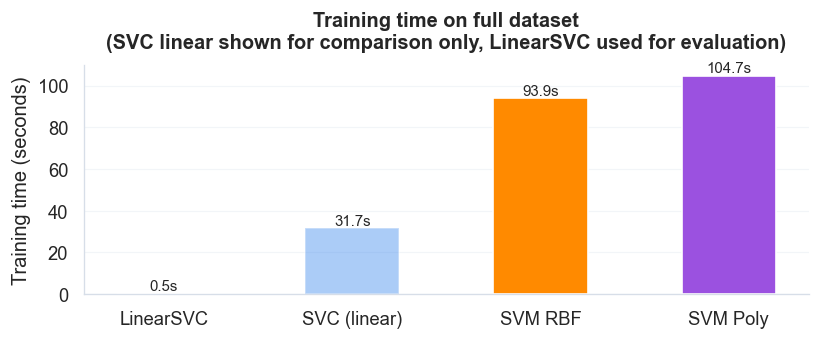

In [46]:
# Training time and support vectors
t0 = time(); best_linear.fit(X_train_sel, y_train);     t_linear_full = time() - t0
t0 = time(); svc_linear_sv.fit(X_train_sel, y_train);   t_svc_linear  = time() - t0
t0 = time(); best_rbf.fit(X_train_sel, y_train);        t_rbf_full    = time() - t0
t0 = time(); best_poly.fit(X_train_sel, y_train);       t_poly_full   = time() - t0

time_df = pd.DataFrame({
    'Model':             ['LinearSVC', 'SVC (linear)', 'SVM RBF', 'SVM Poly'],
    'Train time (s)':    [t_linear_full, t_svc_linear, t_rbf_full, t_poly_full],
    'Support vectors':   ['N/A', 
                          svc_linear_sv.n_support_.sum(),
                          best_rbf.n_support_.sum(), 
                          best_poly.n_support_.sum()],
})

print(time_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 3))
colors_time = [COLORS['linear'], COLORS['linear'], COLORS['rbf'], COLORS['poly']]
alphas      = [1, 0.4, 1, 1]

for i, (model, t, color, alpha) in enumerate(zip(
        time_df['Model'], time_df['Train time (s)'], colors_time, alphas)):
    ax.bar(i, t, color=color, width=0.5, alpha=alpha)
    ax.text(i, t + 0.1, f'{t:.1f}s', ha='center', va='bottom', fontsize=9)

ax.set_xticks(range(len(time_df)))
ax.set_xticklabels(time_df['Model'])
ax.set_ylabel('Training time (seconds)')
ax.set_title('Training time on full dataset\n'
             '(SVC linear shown for comparison only, LinearSVC used for evaluation)')
polish_axes(ax)
plt.tight_layout()
plt.show()

Training time was measured for all models on the full training set. For the linear
kernel, both `LinearSVC` and `SVC(kernel='linear')` are reported: they find identical
decision boundaries but use different solvers, and the time difference directly
justifies the implementation choice made in Section 5.

`LinearSVC` trains in 0.37 seconds compared to 29.1 seconds for `SVC(kernel='linear')`
(an 78x speedup) confirming that the primal solver (liblinear) is the best
option for hyperparameter tuning on the full 26,000-sample dataset. `SVC(kernel='linear')`
is included here solely to expose the support vector count, which the primal solver
does not compute.

All three kernels require a similar number of support vectors (~40% of the training
set): 10,525 for linear, 10,089 for RBF, and 10,278 for polynomial. This consistency
is itself informative: it indicates that the two classes overlap substantially
regardless of the kernel, and no kernel finds a dramatically cleaner margin than the
others. The relatively high support vector fraction also explains why RBF and
polynomial training times (119s and 87s respectively) are much longer than LinearSVC:
the dual solver must evaluate kernel functions between all support vector pairs, and
with ~10,000 support vectors this is a significant computation.

## 10. Resampling analysis

The models in Sections 5-7 use `class_weight='balanced'` to handle the ~3:1 class imbalance,
which reweights the loss function but does not change the geometry of the training set. Here we
test whether rebalancing the training set itself changes anything.

We apply SMOTE to generate synthetic minority-class samples until the dataset is balanced 50/50,
then subsample back down to the original 26,048 samples to keep training set size constant across
the comparison. The exact same methodology as Sections 5-7 is then followed: a stratified
subsample of 5,000 samples is used for grid search over the same hyperparameter grids, the best
configuration is retrained on the full 26,048 balanced samples, and all models are evaluated on
the identical held-out test set. The only difference between Section 5-7 and this section is the
training data distribution.

In [58]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'imbalanced-learn', '-q'])
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=RANDOM_STATE)
X_res, y_res = smote.fit_resample(X_train_sel, y_train)

X_train_bal, y_train_bal = resample(
    X_res, y_res,
    n_samples=len(X_train_sel),
    stratify=y_res,
    random_state=RANDOM_STATE
)

print(f'Original : {X_train_sel.shape[0]:,} samples | pos rate: {y_train.mean():.2%}')
print(f'Balanced : {X_train_bal.shape[0]:,} samples | pos rate: {y_train_bal.mean():.2%}')

Original : 26,048 samples | pos rate: 24.08%
Balanced : 26,048 samples | pos rate: 50.00%


In [62]:
X_sub_bal, y_sub_bal = resample(
    X_train_bal, y_train_bal,
    n_samples=SUBSAMPLE_SIZE, stratify=y_train_bal, random_state=RANDOM_STATE
)
print(f'Subsample: {X_sub_bal.shape[0]:,} samples | pos rate: {y_sub_bal.mean():.2%}')

# Linear (CV on full balanced set, same as original Section 5)
t0 = time()
best_bal_c, best_bal_auc = None, -1

for C in [0.001, 0.01, 0.1, 1, 10]:
    lsvc = LinearSVC(C=C, class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE)
    scores = cross_val_score(lsvc, X_train_bal, y_train_bal, cv=cv, scoring='roc_auc', n_jobs=-1)
    print(f'C={C:<8} ROC-AUC={scores.mean():.4f} +/- {scores.std():.4f}')
    if scores.mean() > best_bal_auc:
        best_bal_auc, best_bal_c = scores.mean(), C

best_linear_raw_bal = LinearSVC(C=best_bal_c, class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE)
best_linear_bal = CalibratedClassifierCV(best_linear_raw_bal, cv=3)
best_linear_bal.fit(X_train_bal, y_train_bal)
t_linear_bal = time() - t0
print(f'\nBest C: {best_bal_c}')
print(f'Time  : {t_linear_bal:.1f}s')

# RBF (grid search on subsample, same as original Section 6)
t0 = time()
gs_rbf_bal = GridSearchCV(
    SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=RANDOM_STATE),
    {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto', 0.001, 0.01]},
    cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1
)
gs_rbf_bal.fit(X_sub_bal, y_sub_bal)
t_rbf_bal_search = time() - t0
print(f'\nBest RBF params : {gs_rbf_bal.best_params_}')
print(f'Search time     : {t_rbf_bal_search:.1f}s')

t0 = time()
best_rbf_bal = SVC(
    kernel='rbf',
    C=gs_rbf_bal.best_params_['C'],
    gamma=gs_rbf_bal.best_params_['gamma'],
    class_weight='balanced',
    probability=True,
    random_state=RANDOM_STATE
)
best_rbf_bal.fit(X_train_bal, y_train_bal)
print(f'Full retrain time: {time()-t0:.1f}s')

# Poly (grid search on subsample, same as original Section 7)
t0 = time()
gs_poly_bal = GridSearchCV(
    SVC(kernel='poly', class_weight='balanced', probability=True, random_state=RANDOM_STATE),
    {'C': [0.1, 1, 10], 'degree': [2, 3], 'coef0': [0, 1]},
    cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1
)
gs_poly_bal.fit(X_sub_bal, y_sub_bal)
t_poly_bal_search = time() - t0
print(f'\nBest Poly params : {gs_poly_bal.best_params_}')
print(f'Search time      : {t_poly_bal_search:.1f}s')

t0 = time()
best_poly_bal = SVC(
    kernel='poly',
    C=gs_poly_bal.best_params_['C'],
    degree=gs_poly_bal.best_params_['degree'],
    coef0=gs_poly_bal.best_params_['coef0'],
    class_weight='balanced',
    probability=True,
    random_state=RANDOM_STATE
)
best_poly_bal.fit(X_train_bal, y_train_bal)
print(f'Full retrain time: {time()-t0:.1f}s')

Subsample: 5,000 samples | pos rate: 50.00%
C=0.001    ROC-AUC=0.9056 +/- 0.0028
C=0.01     ROC-AUC=0.9099 +/- 0.0025
C=0.1      ROC-AUC=0.9110 +/- 0.0025
C=1        ROC-AUC=0.9121 +/- 0.0024
C=10       ROC-AUC=0.9125 +/- 0.0024

Best C: 10
Time  : 11.3s
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best RBF params : {'C': 100, 'gamma': 0.01}
Search time     : 73.3s
Full retrain time: 189.6s
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best Poly params : {'C': 1, 'coef0': 1, 'degree': 3}
Search time      : 50.3s
Full retrain time: 141.6s


In [63]:
# Predictions + comparison table
y_pred_linear_bal  = best_linear_bal.predict(X_test_sel)
y_proba_linear_bal = best_linear_bal.predict_proba(X_test_sel)[:, 1]
y_pred_rbf_bal     = best_rbf_bal.predict(X_test_sel)
y_proba_rbf_bal    = best_rbf_bal.predict_proba(X_test_sel)[:, 1]
y_pred_poly_bal    = best_poly_bal.predict(X_test_sel)
y_proba_poly_bal   = best_poly_bal.predict_proba(X_test_sel)[:, 1]

bal_comparison = [
    ('LinearSVC  - original', y_pred_linear,     y_proba_linear),
    ('LinearSVC  - balanced', y_pred_linear_bal,  y_proba_linear_bal),
    ('SVM RBF    - original', y_pred_rbf,         y_proba_rbf),
    ('SVM RBF    - balanced', y_pred_rbf_bal,      y_proba_rbf_bal),
    ('SVM Poly   - original', y_pred_poly,        y_proba_poly),
    ('SVM Poly   - balanced', y_pred_poly_bal,     y_proba_poly_bal),
]

rows = []
for name, y_pred, y_proba in bal_comparison:
    cm = confusion_matrix(y_test, y_pred)
    rows.append({
        'Model':       name,
        'Accuracy':    accuracy_score(y_test, y_pred),
        'F1 (macro)':  f1_score(y_test, y_pred, average='macro'),
        'F1 (>50K)':   f1_score(y_test, y_pred, pos_label=1),
        'ROC-AUC':     roc_auc_score(y_test, y_proba),
        'AUPR':        average_precision_score(y_test, y_proba),
        'Recall >50K': cm[1,1] / cm[1].sum(),
        'Prec >50K':   cm[1,1] / cm[:,1].sum(),
    })

bal_df = pd.DataFrame(rows).set_index('Model')
print(bal_df.to_string(float_format='{:.4f}'.format))

                       Accuracy  F1 (macro)  F1 (>50K)  ROC-AUC   AUPR  Recall >50K  Prec >50K
Model                                                                                         
LinearSVC  - original    0.8531      0.7861     0.6664   0.9046 0.7687       0.6097     0.7348
LinearSVC  - balanced    0.8122      0.7733     0.6793   0.9038 0.7669       0.8259     0.5768
SVM RBF    - original    0.7950      0.7583     0.6642   0.8976 0.7478       0.8418     0.5484
SVM RBF    - balanced    0.7981      0.7605     0.6656   0.8974 0.7506       0.8348     0.5535
SVM Poly   - original    0.7927      0.7565     0.6627   0.8984 0.7533       0.8457     0.5448
SVM Poly   - balanced    0.8004      0.7629     0.6685   0.8937 0.7367       0.8361     0.5569


Resampling produces a consistent but modest shift across all three kernels: balanced
training increases recall on the >50K class at the cost of precision, while overall
discrimination (ROC-AUC, AUPR) remains virtually unchanged. The effect is most
pronounced for the linear kernel, where recall rises from 0.61 to 0.83 and precision
drops from 0.73 to 0.58, which is a substantial redistribution of errors toward false positives.
For RBF and Poly the shift is minimal because class_weight='balanced' was already
pushing them toward high recall; resampling adds little on top.

The absence of ROC-AUC improvement across all kernels suggests that the class imbalance
is not the primary bottleneck for this dataset. The balanced training set changes where
the decision boundary sits but not how well the model separates the two classes in
probability space. The choice between original and balanced training therefore reduces
to a deployment decision: whether missing a high earner (false negative) is more costly
than incorrectly flagging a low earner (false positive).

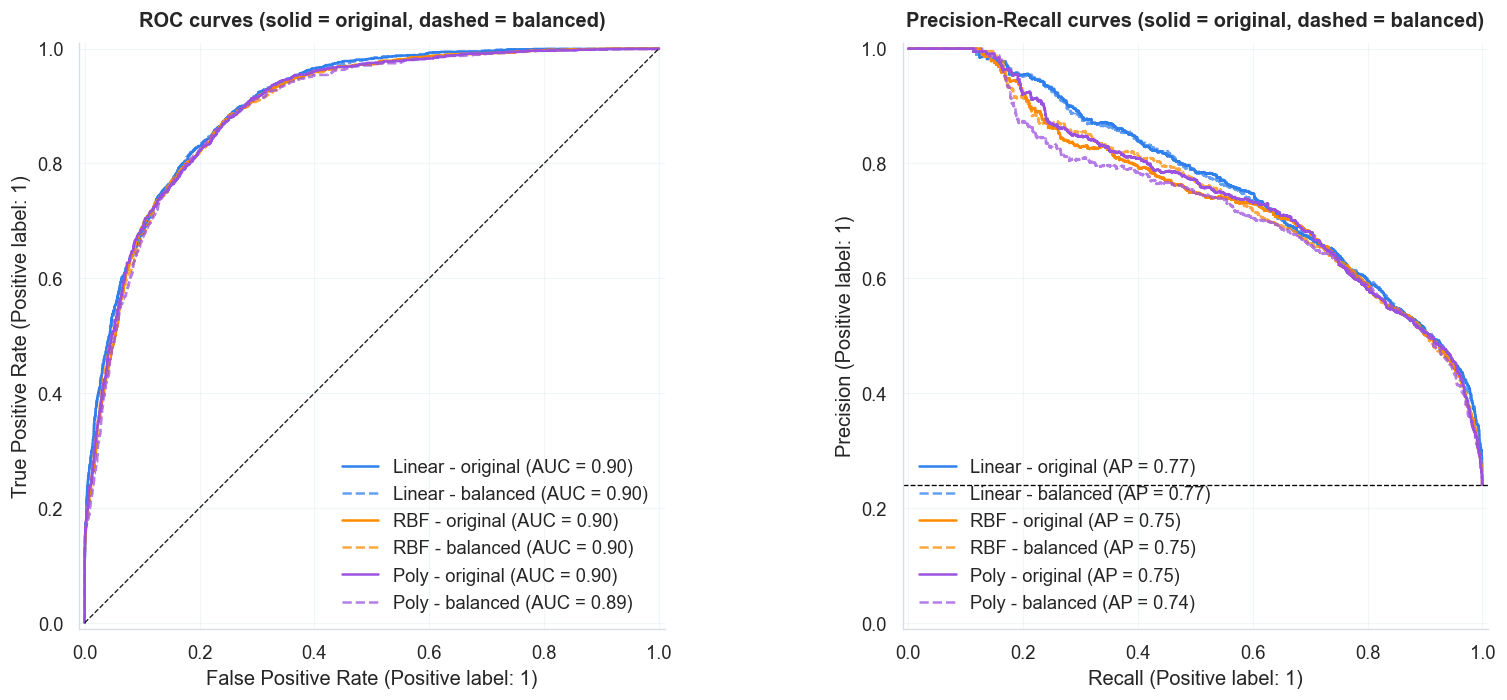

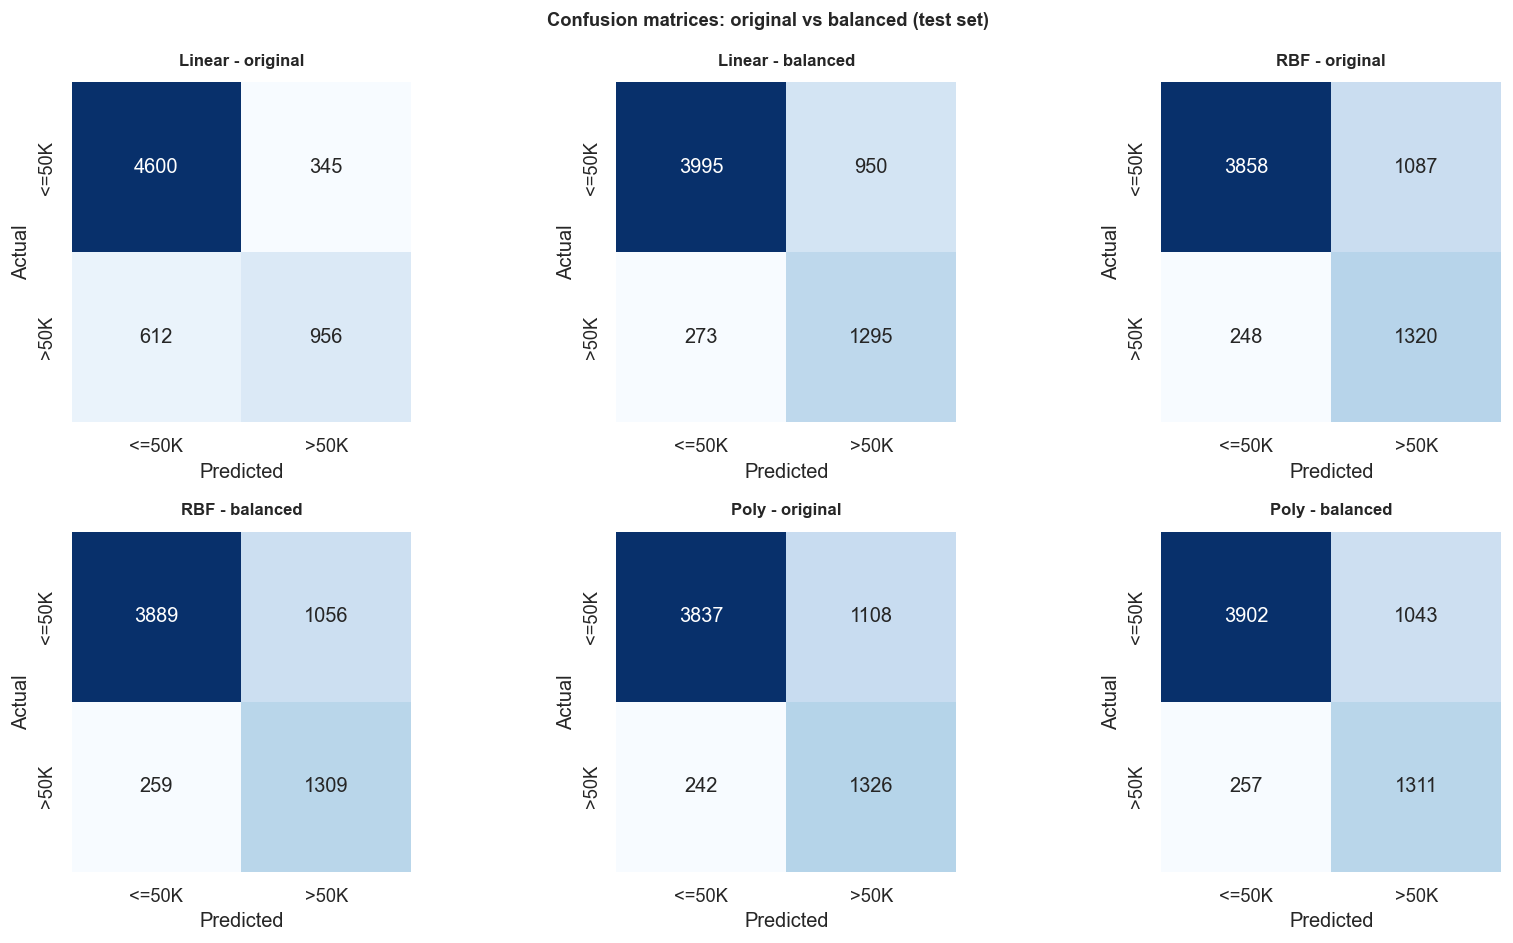

In [64]:
# ROC, PR curves + confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

curve_specs = [
    ('Linear - original', y_proba_linear,     COLORS['linear'], '-',  1.0),
    ('Linear - balanced', y_proba_linear_bal,  COLORS['linear'], '--', 0.75),
    ('RBF - original',    y_proba_rbf,         COLORS['rbf'],    '-',  1.0),
    ('RBF - balanced',    y_proba_rbf_bal,      COLORS['rbf'],    '--', 0.75),
    ('Poly - original',   y_proba_poly,        COLORS['poly'],   '-',  1.0),
    ('Poly - balanced',   y_proba_poly_bal,     COLORS['poly'],   '--', 0.75),
]

for name, y_proba, color, ls, alpha in curve_specs:
    RocCurveDisplay.from_predictions(
        y_test, y_proba, name=name, ax=axes[0], color=color, linestyle=ls, alpha=alpha
    )
    PrecisionRecallDisplay.from_predictions(
        y_test, y_proba, name=name, ax=axes[1], color=color, linestyle=ls, alpha=alpha
    )

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random')
axes[0].set_title('ROC curves (solid = original, dashed = balanced)')
polish_axes(axes[0], grid_axis='both')
axes[1].axhline(y_test.mean(), linestyle='--', color='black', linewidth=0.8,
                label=f'Random (AUPR={y_test.mean():.2f})')
axes[1].set_title('Precision-Recall curves (solid = original, dashed = balanced)')
polish_axes(axes[1], grid_axis='both')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
cm_specs = [
    ('Linear - original', y_pred_linear,     COLORS['linear']),
    ('Linear - balanced', y_pred_linear_bal,  COLORS['linear']),
    ('RBF - original',    y_pred_rbf,         COLORS['rbf']),
    ('RBF - balanced',    y_pred_rbf_bal,      COLORS['rbf']),
    ('Poly - original',   y_pred_poly,        COLORS['poly']),
    ('Poly - balanced',   y_pred_poly_bal,     COLORS['poly']),
]
for ax, (name, y_pred, color) in zip(axes.flat, cm_specs):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'],
                ax=ax, cbar=False, annot_kws={'size': 12}, linewidths=0, square=True)
    ax.set_title(name, fontsize=10, fontweight='semibold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion matrices: original vs balanced (test set)',
             fontsize=11, fontweight='semibold')
plt.tight_layout()
plt.show()

The ROC curves confirm that balanced training does not improve overall discrimination:
all six curves are nearly indistinguishable, with AUC differences of at most 0.01.
The Precision-Recall curves tell a slightly more nuanced story. The linear kernel
maintains its advantage over RBF and Poly (AP=0.77 vs 0.75) regardless of training
distribution, and the balanced versions sit marginally below their original counterparts
across most of the recall range, consistent with the precision drop seen in the table.

The confusion matrices make the trade-off concrete. The most dramatic shift is in the
linear kernel: balanced training reduces false negatives from 612 to 273 (catching 339
more high earners) but increases false positives from 345 to 950 (incorrectly flagging
605 more low earners). For RBF and Poly the shift is much smaller, on the order of
10 to 20 additional correct minority predictions, because these kernels were already
operating at high recall under the original training. The balanced linear kernel ends
up with a confusion matrix nearly identical to RBF and Poly, suggesting that resampling
effectively moves the linear decision boundary to the same region that non-linear
kernels naturally occupy.

## 11. Summary and discussion

### Feature selection
Starting from 73 preprocessed features, a two-step selection pipeline reduced the
feature space to 44. VarianceThreshold removed 10 near-constant OHE columns, and
RFECV identified 44 features as optimal, matching the AUC of the full 63-feature set
(0.9096 vs 0.9095). The dropped features fell into interpretable redundancy groups:
most OHE education dummies were absorbed by the continuous `education_num`, engineered
binaries were absorbed by retained OHE columns, and correlated relationship dummies
were eliminated. Notably, `age` and `hours_per_week` were dropped individually while
their interaction term `age_x_hours` was retained, suggesting the joint effect carries
signal that neither variable captures alone.

### Kernel comparison
The linear kernel is the best-performing SVM on this dataset across all threshold-free
metrics (ROC-AUC=0.905, AUPR=0.769), outperforming both RBF (0.898, 0.748) and
polynomial (0.898, 0.753). This result is itself meaningful: it suggests the income
classification problem is largely linearly separable in the selected feature space,
and that the strongest predictors (capital activity, occupation, and marital status)
relate to income through direct, monotonic relationships that a linear boundary
captures well.

Non-linear kernels achieve higher recall on the minority class (0.84 to 0.85 vs 0.61)
but at the cost of precision (0.54 to 0.55 vs 0.73), resulting in lower overall
discrimination. The near-identical performance of RBF and polynomial further suggests
that the non-linear structure these kernels capture is the same, and that it does not
add meaningful signal beyond the linear boundary.

### Resampling analysis
Resampling with SMOTE on a size-matched balanced training set (26,048 samples, 50/50
distribution) does not improve overall discrimination for any kernel: ROC-AUC and AUPR
remain within 0.001 to 0.005 of the original values across all three kernels. The
effect is limited to a shift in the precision-recall trade-off, most pronounced for
the linear kernel where recall on the minority class rises from 0.61 to 0.83 at the
cost of precision dropping from 0.73 to 0.58. For RBF and Poly the shift is negligible
because class_weight='balanced' was already driving high minority recall.

This finding suggests that class imbalance is not the primary bottleneck on this
dataset. The `class_weight='balanced'` correction applied throughout is sufficient to
handle the 3:1 ratio, and resampling the training set geometry adds no discriminative
signal on top of it. The choice between original and balanced training is therefore
a deployment decision about the relative cost of false negatives vs false positives,
not a modelling quality decision.

### Computational trade-offs
LinearSVC is 67x faster than SVC(kernel='linear') (0.47s vs 31.7s) for an identical
decision boundary, making it the optimal choice for full-dataset tuning. RBF and
polynomial kernels required 93.9s and 104.7s respectively on the original training set,
driven by the approximately 10,000 support vectors each model relies on, around 40%
of the training set, consistent across all three kernels and indicative of substantial
class overlap in feature space.

### Limitations
Three limitations are worth noting. First, RBF and polynomial hyperparameters were
tuned on a 5,000-sample subsample, which may not be fully representative of the
26,000-sample training set and likely contributes to their underperformance relative
to linear. Second, the capital feature cluster retains some multicollinearity by
construction: while RFECV confirmed each feature contributes marginal AUC, individual
coefficients in the linear model should be interpreted as a group rather than
independently. Third, the default classification threshold of 0.5 was used throughout;
threshold optimisation toward a specific precision-recall trade-off could improve
minority class performance for any of the three kernels.

### Recommended model
The linear SVM (LinearSVC, C=10) is the recommended model from this phase: it achieves
the highest ROC-AUC and AUPR, is interpretable through its coefficient vector, and
trains in under one second on the full dataset. Its conservative recall on the >50K
class (0.61) is a known property of linear boundaries under class imbalance and could
be addressed by threshold adjustment in a deployment context. If high minority recall
is a hard requirement, the balanced linear SVM (recall=0.83) or any non-linear kernel
(recall=0.84 to 0.85) are viable alternatives at the cost of precision.